Starting Time Series Analysis for Presentation...
Step 1: Loading and Preparing Data...
Data loaded, filtered, and resampled to monthly frequency for 'pm2_5'.
Step 2: Plotting the raw data...


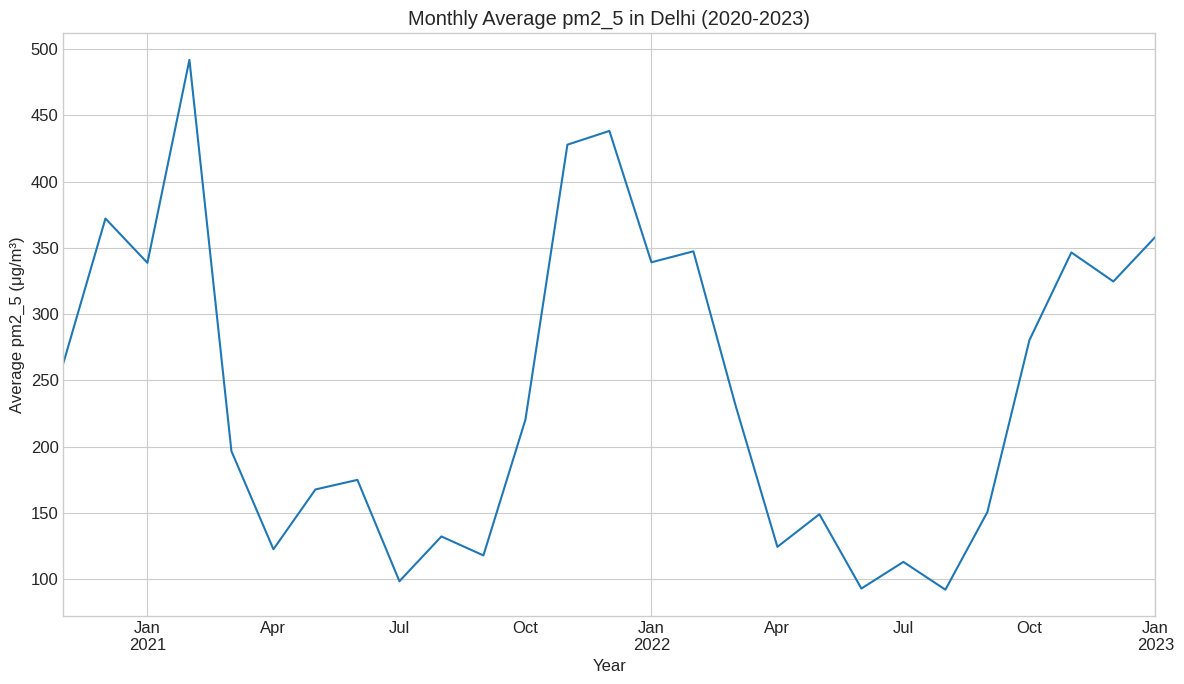

Step 3: Decomposing the time series...


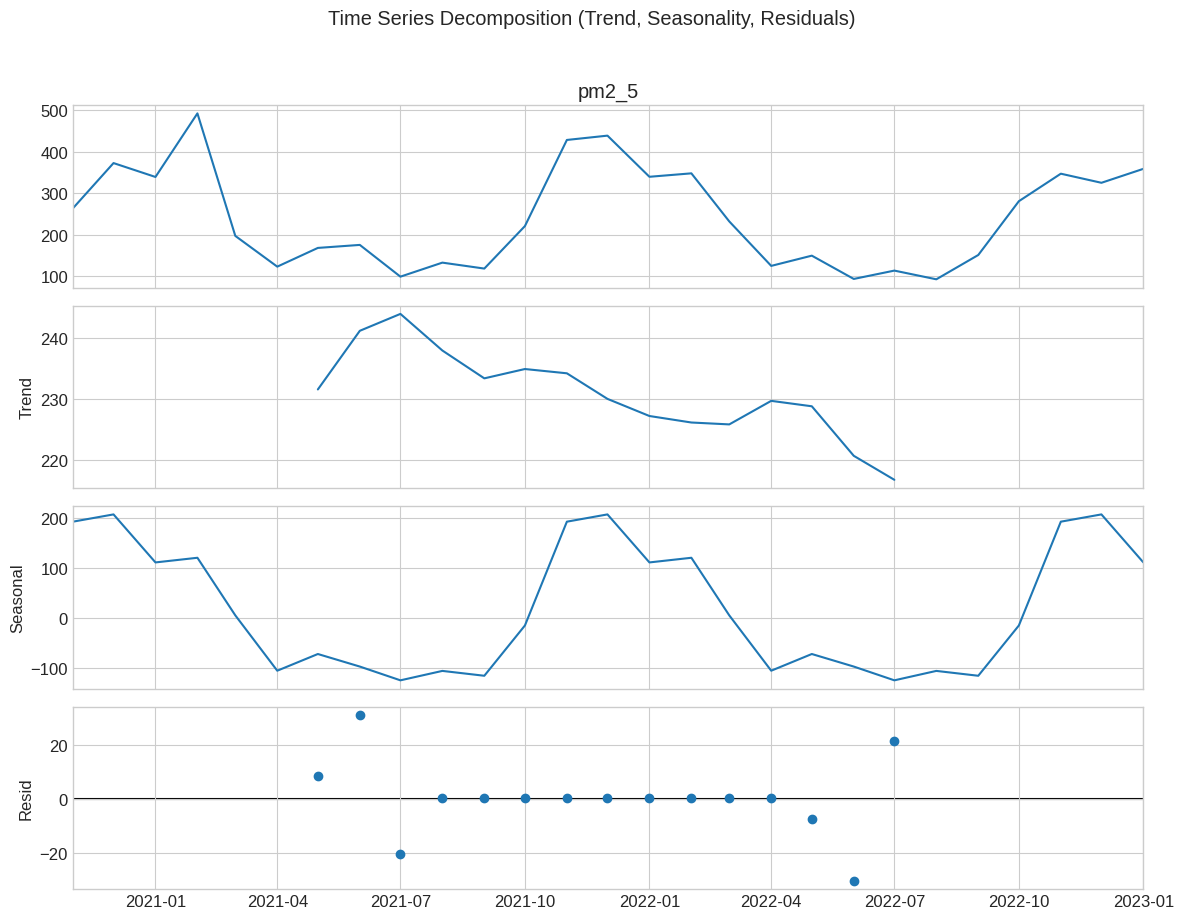

Step 4: Fitting a simplified AR model with seasonality (d=0, D=0)...
Step 5: Plotting model diagnostics...


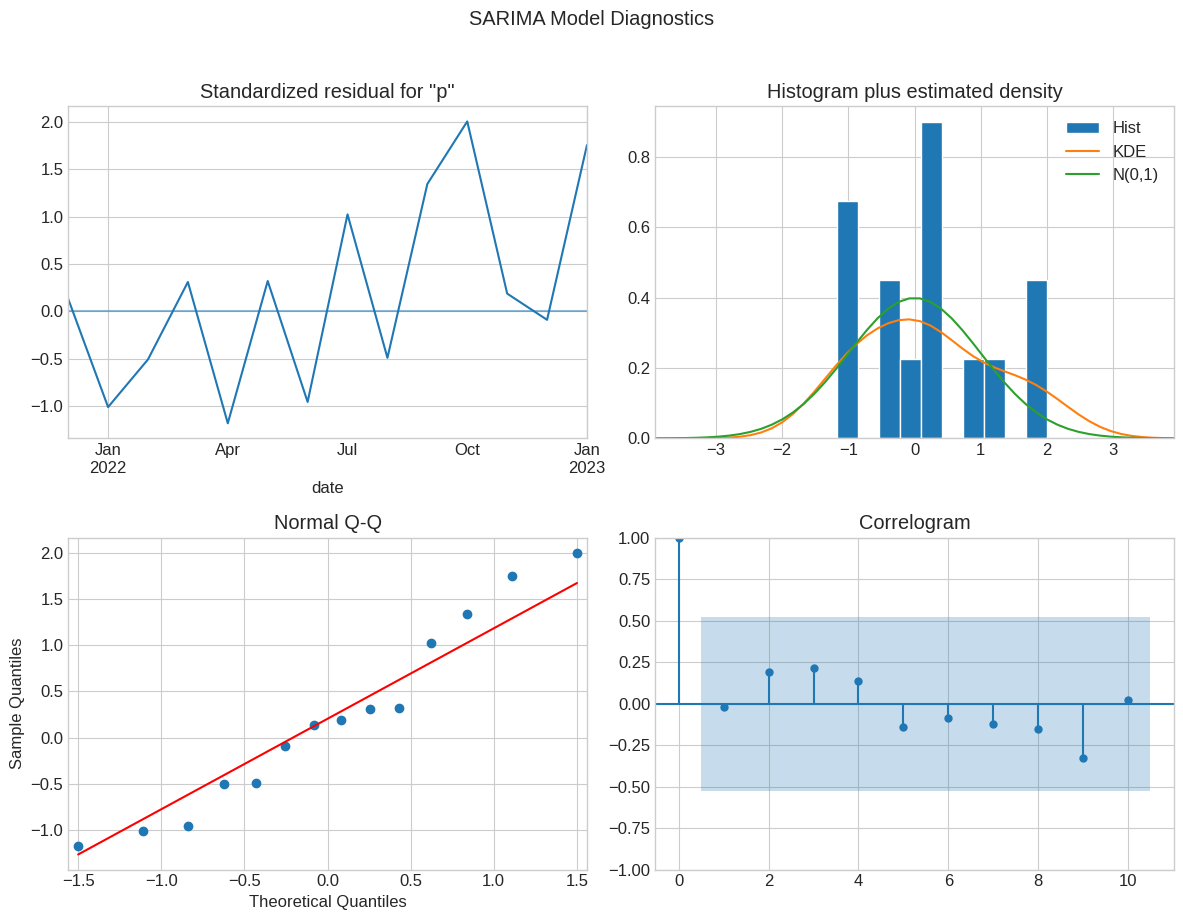

Step 6: Generating and plotting the forecast...


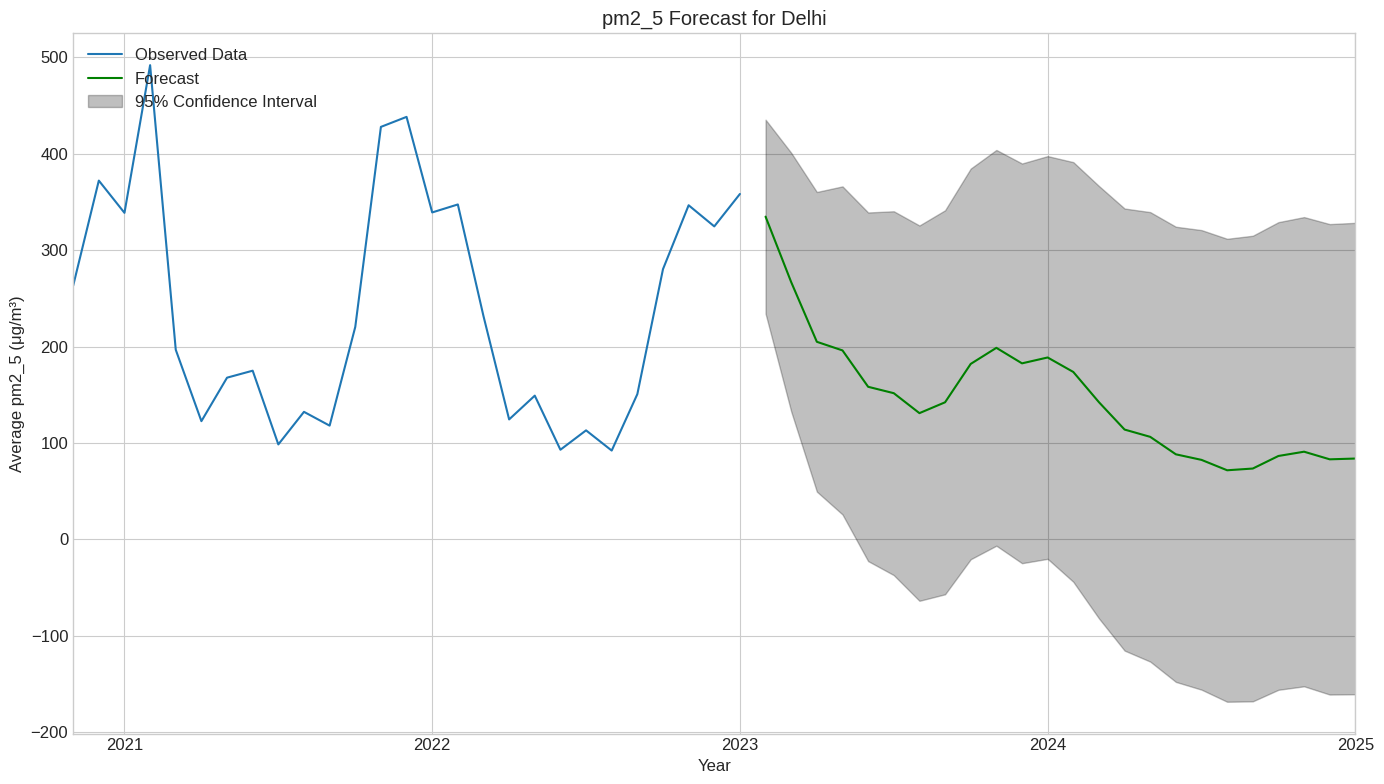

Time series analysis complete!


In [ ]:
# Time Series analysis of Delhi's AQI
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import warnings

# warniing  suppresion
warnings.filterwarnings("ignore")

# Set default plot style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['font.size'] = 12

# data preprocessing
file_path = 'delhi_aqi.csv'

# we'll use 'pm2_5' for AQI analysis
TARGET_COLUMN = 'pm2_5'
CITY_NAME = 'Delhi'
try:
    data = pd.read_csv(file_path)

    # Convert 'date' column to datetime objects (CRITICAL for time series)
    data['date'] = pd.to_datetime(data['date'])
    data = data.set_index('date')


    data[TARGET_COLUMN] = data[TARGET_COLUMN].interpolate(method='time')

    data[TARGET_COLUMN] = data[TARGET_COLUMN].fillna(method='bfill')

    # The data is hourly, but the main cycle is YEARLY so we resample to 'Monthly Start' ('MS')
    # We use .mean() to get the average PM2.5 for each month.
    y = data[TARGET_COLUMN].resample('MS').mean()

    print(f"Data loaded, filtered, and resampled to monthly frequency for '{TARGET_COLUMN}'.")

    plt.figure()
    y.plot(title=f'Monthly Average {TARGET_COLUMN} in {CITY_NAME} (2020-2023)')
    plt.ylabel(f'Average {TARGET_COLUMN} (μg/m³)')
    plt.xlabel('Year')
    plt.tight_layout()
    plt.show()

    # Decomposing the Time Series
    # We'll use seasonal_decompose to split the data into its 3 components.
    decomposition = sm.tsa.seasonal_decompose(y, model='additive')

    # Plot the decomposition
    fig = decomposition.plot()
    fig.set_size_inches(12, 9)
    fig.suptitle('Time Series Decomposition (Trend, Seasonality, Residuals)', y=1.02)
    plt.tight_layout()
    plt.show()

    #  Modeling with SARIMA
    # We'll fit a simple AR(1) model with a Seasonal AR(1) component.

    mod = sm.tsa.statespace.SARIMAX(y,
                                    order=(1, 0, 0),
                                    seasonal_order=(1, 0, 0, 12),
                                    enforce_stationarity=False,
                                    enforce_invertibility=False)

    results = mod.fit(disp=False)

    # model diagnostics
    fig_diag = results.plot_diagnostics(figsize=(12, 9))
    fig_diag.suptitle("SARIMA Model Diagnostics", y=1.02)
    plt.tight_layout()
    plt.show()

    # Forecasting
    # forecast for the next 24 steps (2 years)
    pred_forecast = results.get_forecast(steps=24)

    # confidence intervals for the forecast
    pred_ci = pred_forecast.conf_int()

    plt.figure()
    ax = y.plot(label='Observed Data', figsize=(14, 8))

    pred_forecast.predicted_mean.plot(ax=ax, label='Forecast', color='green')

    ax.fill_between(pred_ci.index,
                    pred_ci.iloc[:, 0],
                    pred_ci.iloc[:, 1], color='k', alpha=.25, label='95% Confidence Interval')

    ax.set_xlabel('Year')
    ax.set_ylabel(f'Average {TARGET_COLUMN} (μg/m³)')
    ax.set_title(f'{TARGET_COLUMN} Forecast for {CITY_NAME}')
    plt.legend(loc='upper left')
    plt.tight_layout()
    plt.show()

    print("Time series analysis complete!")

except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found.")
    print("Please make sure it is in the same directory as the script.")
except Exception as e:
    print(f"An error occurred: {e}")
    print("Please ensure you have pandas, matplotlib, and statsmodels installed:")
    print("pip install pandas matplotlib statsmodels")